# 01 — GPU Hardware Roadmap & Trends

This notebook visualizes the GPU hardware roadmap used by the DC-TCO framework,
including known GPUs (P100 through B200) and projected future generations.

In [1]:
import sys
sys.path.insert(0, '..')

from dc_tco.config import load_config
from dc_tco.hardware import build_gpu_roadmap, build_server_roadmap
from dc_tco.plotting import plot_gpu_trends

In [3]:
cfg = load_config('../configs/default.yaml')
gpu_roadmap = build_gpu_roadmap(cfg)

print(f'GPU roadmap: {len(gpu_roadmap)} generations\n')
for g in gpu_roadmap:
    tag = '' if not g.code_name.startswith('Future') else ' (projected)'
    print(f'  {g.code_name:<20s} Q{g.release_quarter:>3d}  '
          f'TDP={g.tdp:>7.0f}W  TFLOPS={g.tflops:>7.1f}  '
          f'MemBW={g.mem_bw:>7.0f}GB/s NetBW={g.net_bw:>7.0f}GB/s Cost=${g.cost:>8.0f}{tag}')

GPU roadmap: 12 generations

  P100                 Q  4  TDP=    300W  TFLOPS=   21.2  MemBW=    732GB/s NetBW=    160GB/s Cost=$    9428
  V100                 Q 12  TDP=    250W  TFLOPS=   31.3  MemBW=    897GB/s NetBW=    300GB/s Cost=$   11458
  A100                 Q 25  TDP=    400W  TFLOPS=   78.0  MemBW=   2090GB/s NetBW=    600GB/s Cost=$   18000
  H100                 Q 35  TDP=    700W  TFLOPS=  267.6  MemBW=   3440GB/s NetBW=    900GB/s Cost=$   27000
  H200                 Q 39  TDP=    700W  TFLOPS=  267.6  MemBW=   5007GB/s NetBW=    900GB/s Cost=$   35000
  B100                 Q 41  TDP=   1000W  TFLOPS=  248.3  MemBW=   4200GB/s NetBW=   1800GB/s Cost=$   30000
  B200                 Q 43  TDP=   1000W  TFLOPS=  248.3  MemBW=   4200GB/s NetBW=   1800GB/s Cost=$   40000
  FutureGPU_2026       Q 47  TDP=    970W  TFLOPS=  298.7  MemBW=   4919GB/s NetBW=   1629GB/s Cost=$   38002 (projected)
  FutureGPU_2027       Q 51  TDP=   1045W  TFLOPS=  327.3  MemBW=   5346GB/s Ne

Text(0.5, 1.02, 'GPU Roadmap Trends (Known + Projected)')

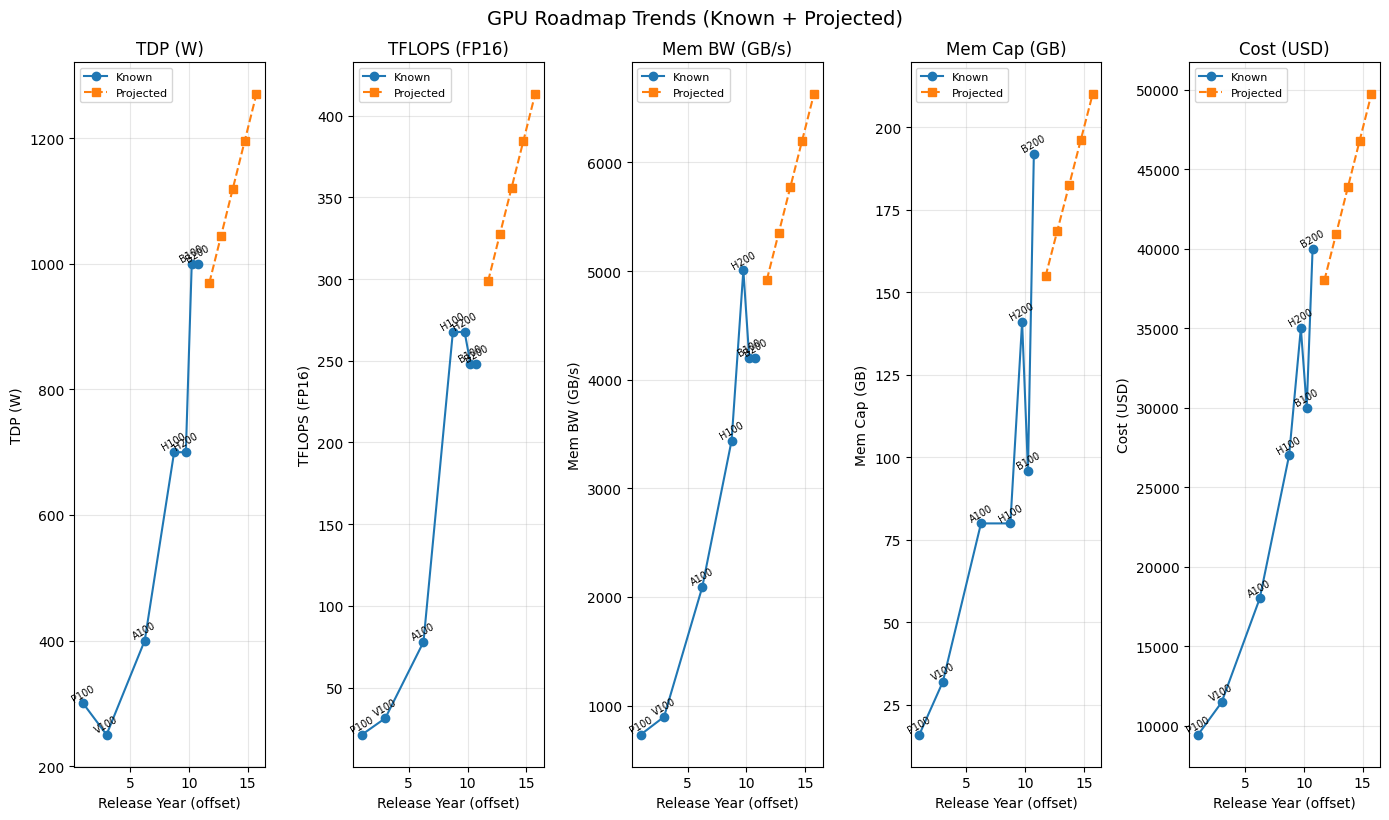

In [4]:
fig = plot_gpu_trends(gpu_roadmap)
fig.suptitle('GPU Roadmap Trends (Known + Projected)', fontsize=14, y=1.02)

## Server-Level Specs

Each server packages 8 GPUs. Server TDP includes a power overhead factor (default 0.5).

In [5]:
server_roadmap = build_server_roadmap(cfg)

print(f'Server roadmap: {len(server_roadmap)} generations\n')
for s in server_roadmap:
    print(f'  {s.code_name:<20s} Q{s.release_quarter:>3d}  '
          f'TDP={s.tdp:>8.0f}W  TFLOPS={s.tflops:>8.1f}  MemBW={s.mem_bw:>8.0f}GB/s  MemCap={s.mem_cap:>8.0f}GB  NetBW={s.net_bw:>8.0f}GB/s  Cost=${s.cost:>9.0f}')

Server roadmap: 12 generations

  P100                 Q  4  TDP=    4800W  TFLOPS=    21.2  MemBW=    5858GB/s  MemCap=     128GB  NetBW=    1280GB/s  Cost=$    75424
  V100                 Q 12  TDP=    4000W  TFLOPS=    31.3  MemBW=    7176GB/s  MemCap=     256GB  NetBW=    2400GB/s  Cost=$    91664
  A100                 Q 25  TDP=    6400W  TFLOPS=    78.0  MemBW=   16720GB/s  MemCap=     640GB  NetBW=    4800GB/s  Cost=$   144000
  H100                 Q 35  TDP=   11200W  TFLOPS=   267.6  MemBW=   27520GB/s  MemCap=     640GB  NetBW=    7200GB/s  Cost=$   216000
  H200                 Q 39  TDP=   11200W  TFLOPS=   267.6  MemBW=   40056GB/s  MemCap=    1128GB  NetBW=    7200GB/s  Cost=$   280000
  B100                 Q 41  TDP=   16000W  TFLOPS=   248.3  MemBW=   33600GB/s  MemCap=     768GB  NetBW=   14400GB/s  Cost=$   240000
  B200                 Q 43  TDP=   16000W  TFLOPS=   248.3  MemBW=   33600GB/s  MemCap=    1536GB  NetBW=   14400GB/s  Cost=$   320000
  FutureGPU_2026

## Changing Projection Mode

You can change how future GPUs are projected by modifying the config:

Text(0.5, 1.02, 'Exponential Projection Mode')

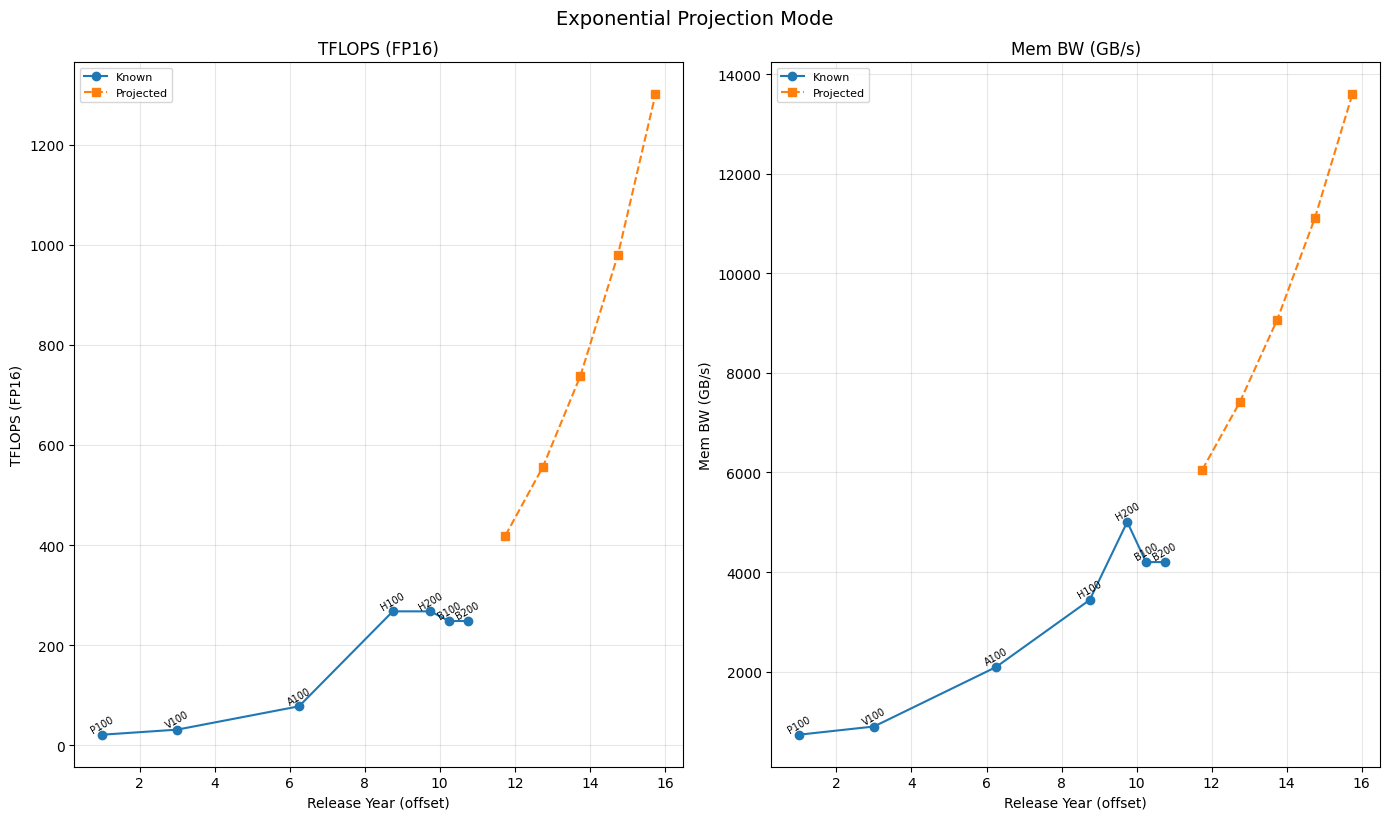

In [6]:
import copy

cfg_exp = copy.deepcopy(cfg)
cfg_exp.hardware.projection.tflops = 'exponential'
cfg_exp.hardware.projection.mem_bw = 'exponential'

gpu_exp = build_gpu_roadmap(cfg_exp)
fig = plot_gpu_trends(gpu_exp, metrics=['tflops', 'mem_bw'])
fig.suptitle('Exponential Projection Mode', fontsize=14, y=1.02)